### OpenSea NFT 경매(Auction) 거래 분류 — 이진(Binary) 버전
##### Collectibles vs 나머지
- 원본은 5개 카테고리 다중분류였으나, 비중이 가장 큰 `Collectibles`를 양성(1)으로 두고 나머지(Art, Virtual Worlds, Utility, Trading Cards)를 음성(0)으로 묶은 이진분류 태스크로 전환.
- 실제 활용 맥락: **NFT 마켓플레이스의 "Collectibles" 자동 카테고리 태깅**.
- Collectibles 필터에 엉뚱한 카테고리가 섞이면 컬렉터 탐색 경험이 망가지므로 **정밀도(Precision)** 가 중요한 시나리오.


##### feature
- year / month / hour / day_of_week / is_weekend: 거래 시각 기반 파생
- total_price_eth: 거래 금액 (log1p)
- payment_token_usd_price: 결제 토큰 USD 환율 (log1p)
- num_sales: 자산 누적 판매 횟수 (log1p)
- payment_token: 결제 토큰 종류 (Ether / Wrapped Ether / Other) — One-Hot
- 컬렉션 단위 집계 (split 후 train 기준으로만 계산):
    - collection_freq: 컬렉션 거래 빈도 (log1p)
    - collection_price_mean / collection_price_std: 컬렉션 가격 평균/표준편차
    - collection_num_sales_mean: 컬렉션 평균 재판매 횟수

##### target
- is_collectibles: 1 = Collectibles, 0 = 나머지 4개 카테고리


In [1]:
import pandas as pd

nft_df = pd.read_csv('./datasets/OpenSea_NFT_Sales_2019_2021.csv', low_memory=False)
nft_df = nft_df.sample(n=100000, random_state=124).reset_index(drop=True)
nft_df

,sales_datetime,id,asset.id,asset.name,asset.collection.name,asset.collection.short_description,asset.permalink,total_price,payment_token.name,payment_token.usd_price,asset.num_sales,seller.address,seller.user.username,winner_account.address,Category
0,2021-08-28 08:25:45,668754486,41120300,Chad #8727,Chads NFT,NaN,https://opensea.io/assets/0x9cf63efbe189091b7e...,40000000000000000,Ether,3644.46,1,0x376078ab164faba5891f77e70bab2eb4e1b89c3a,Stryker884,0xe3f4b8781381c36d5c6951ceee2fe35dd9cf3e63,Collectibles
1,2021-08-22 16:40:20,602091373,34354715,PixelCat 5386,24px,NaN,https://opensea.io/assets/0x495f947276749ce646...,240000000000000000,Ether,3689.36,3,0xde4db74a280f55f649bb20c845af12f95223eae7,jayto,0x3ff23183a9c70665c14831e10cc6297b6ffd157c,Collectibles
2,2020-12-04 19:58:15,75605864,17165153,"BFH Sphere: #40560004, Lv: 53",Brave Frontier Heroes,NaN,https://opensea.io/assets/0xc03844f07f86ad1d90...,25000000000000000,Ether,3815.21,1,0xa63c72f57eaec7bef6cf6ce5c61cfde05dae9fcf,PoP,0x3c325dae6ca198631b4a9f4b9f5d7e1bd6d8ab6b,Virtual Worlds
3,2021-02-27 18:54:18,80692740,18269838,Spaced Out,Meme Ltd.,NaN,https://opensea.io/assets/0xe4605d46fd0b3f8329...,3940000000000000000,Ether,3815.21,18,0x905213a93f0d202462c3379301e62a74c4aa56ec,bhaiko,0xab6ca2017548a170699890214bfd66583a0c1754,Collectibles
4,2021-10-18 05:28:28,1421732447,57615801,Wassie 11915,loomlocknft (Wassies),NaN,https://opensea.io/assets/0x1d20a51f088492a0f1...,1100000000000000000,Ether,3827.27,1,0x92877703f0f38e0740e43ed7fe414a2dbbbec3fb,NaN,0x58e2f48948a90cd89245117e5366268b3560d990,Collectibles
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2021-08-18 04:41:28,562550091,37376378,Wicked Ape #9046,Wicked Ape Bone Club,NaN,https://opensea.io/assets/0xbe6e3669464e7db1e1...,250000000000000000,Ether,3732.09,1,0x2491403bd141d8aa64425b612987dc0a4cf8d265,NaN,0xda6776bfba3252e6720911c4ed6a317e98d4954f,Collectibles
99996,2021-12-02 10:39:17,2281055214,125032673,Crypto bull #165,Crypto Bull Society,NaN,https://opensea.io/assets/0x469823c7b84264d1ba...,1888000000000000000,Ether,3833.11,1,0x62941f356d3970e8d664dec2c582ee2ec3805548,DaOhGee,0x957b9ddcb99fe4bce41da4e6d8e61ef2cc3af055,Collectibles
99997,2021-10-04 02:43:45,1229942571,51591207,Pythagorean Mask # 2664,Pythagorean Masks,NaN,https://opensea.io/assets/0x6327f6305331f7e0cc...,27000000000000000,Ether,3824.22,1,0xf266ec07bced0c64514dc0f7ab1bbc56dc2aff9c,Oliverrr,0x4450bd53845e47a337bdd4248144ccad289fd56b,Collectibles
99998,2021-08-23 23:13:21,617239121,34149131,Flowers #5672,Flowers by RVig,NaN,https://opensea.io/assets/0xa7d8d9ef8d8ce8992d...,250000000000000000,Ether,3689.36,2,0xc39c550825fdf5d44eab12d0bb319ae3144ba557,jsunNFT,0x0e5a1d84ed69067c078596bc6a17452425b005f1,Art


In [2]:
nft_df.isna().sum()

sales_datetime                            0
id                                        0
asset.id                                  0
asset.name                             5799
asset.collection.name                   935
asset.collection.short_description    99020
asset.permalink                         935
total_price                               0
payment_token.name                       29
payment_token.usd_price                  60
asset.num_sales                           0
seller.address                            0
seller.user.username                  11162
winner_account.address                    0
Category                                  0
dtype: int64

In [3]:
nft_df.duplicated().sum()

np.int64(0)

In [4]:
import numpy as np

# 시각 파생
nft_df['sales_datetime'] = pd.to_datetime(nft_df['sales_datetime'], errors='coerce')
nft_df['year']        = nft_df['sales_datetime'].dt.year
nft_df['month']       = nft_df['sales_datetime'].dt.month
nft_df['hour']        = nft_df['sales_datetime'].dt.hour
nft_df['day_of_week'] = nft_df['sales_datetime'].dt.dayofweek
nft_df['is_weekend']  = (nft_df['day_of_week'] >= 5).astype(int)

# 수치 피처: log1p로 heavy-tail 완화
nft_df['total_price_eth']        = np.log1p(nft_df['total_price'].astype(float) / 1e18)
nft_df['payment_token_usd_price'] = np.log1p(
    nft_df['payment_token.usd_price'].astype(float).clip(lower=0))
nft_df['num_sales']              = np.log1p(nft_df['asset.num_sales'].astype(float))

# payment_token 그룹화
def group_token(name):
    if name == 'Ether':          return 'Ether'
    if name == 'Wrapped Ether':  return 'Wrapped Ether'
    return 'Other'

nft_df['payment_token']   = nft_df['payment_token.name'].apply(group_token)
nft_df['collection_name'] = nft_df['asset.collection.name'].fillna('unknown')

cols = ['year', 'month', 'hour', 'day_of_week', 'is_weekend',
        'total_price_eth', 'payment_token_usd_price', 'num_sales',
        'collection_name', 'payment_token', 'Category']
nft_df = nft_df[cols].dropna().reset_index(drop=True)

# Uncategorized 제거 + 주요 5 카테고리만 유지
keep_categories = ['Collectibles', 'Art', 'Virtual Worlds', 'Utility', 'Trading Cards']
nft_df = nft_df[nft_df.Category.isin(keep_categories)].reset_index(drop=True)

print('이진 변환 전 카테고리 분포:')
print(nft_df.Category.value_counts())

# ===== 이진 변환: Collectibles(최다)=1, 나머지=0 =====
nft_df['is_collectibles'] = (nft_df.Category == 'Collectibles').astype(int)
nft_df = nft_df.drop(columns=['Category'])

print()
print('이진 변환 후 분포 (1=Collectibles, 0=나머지):')
print(nft_df.is_collectibles.value_counts())
print(f'양성 비율: {nft_df.is_collectibles.mean():.4f}')

nft_df

이진 변환 전 카테고리 분포:
Category
Collectibles      55168
Art               21829
Virtual Worlds     5377
Utility            4695
Trading Cards      1604
Name: count, dtype: int64

이진 변환 후 분포 (1=Collectibles, 0=나머지):
is_collectibles
1    55168
0    33505
Name: count, dtype: int64
양성 비율: 0.6222


,year,month,hour,day_of_week,is_weekend,total_price_eth,payment_token_usd_price,num_sales,collection_name,payment_token,is_collectibles
0,2021,8,8,5,1,0.039221,8.201238,0.693147,Chads NFT,Ether,1
1,2021,8,16,6,1,0.215111,8.213479,1.386294,24px,Ether,1
2,2020,12,19,4,0,0.024693,8.247013,0.693147,Brave Frontier Heroes,Ether,0
3,2021,2,18,5,1,1.597365,8.247013,2.944439,Meme Ltd.,Ether,1
4,2021,10,5,0,0,0.741937,8.250168,0.693147,loomlocknft (Wassies),Ether,1
...,...,...,...,...,...,...,...,...,...,...,...
88668,2021,8,4,2,0,0.223144,8.224992,0.693147,Wicked Ape Bone Club,Ether,1
88669,2021,12,10,3,0,1.060564,8.251693,0.693147,Crypto Bull Society,Ether,1
88670,2021,10,2,0,0,0.026642,8.249371,0.693147,Pythagorean Masks,Ether,1
88671,2021,8,23,0,0,0.223144,8.213479,1.098612,Flowers by RVig,Ether,0


In [5]:
nft_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,88673.0,2020.945620,0.287706,2.019000e+03,2021.000000,2021.000000,2021.000000,2021.000000
month,88673.0,9.125856,2.036980,1.000000e+00,8.000000,9.000000,10.000000,12.000000
hour,88673.0,11.684086,7.355215,0.000000e+00,5.000000,12.000000,18.000000,23.000000
day_of_week,88673.0,2.969630,2.027851,0.000000e+00,1.000000,3.000000,5.000000,6.000000
is_weekend,88673.0,0.284100,0.450987,0.000000e+00,0.000000,0.000000,1.000000,1.000000
total_price_eth,88673.0,0.310852,0.569560,0.000000e+00,0.058269,0.139762,0.332894,18.826146
payment_token_usd_price,88673.0,8.191350,0.562433,7.100000e-11,8.225765,8.230812,8.246376,8.325204
num_sales,88673.0,1.390342,1.427154,0.000000e+00,0.693147,1.098612,1.386294,9.807472
is_collectibles,88673.0,0.622151,0.484852,0.000000e+00,0.000000,1.000000,1.000000,1.000000


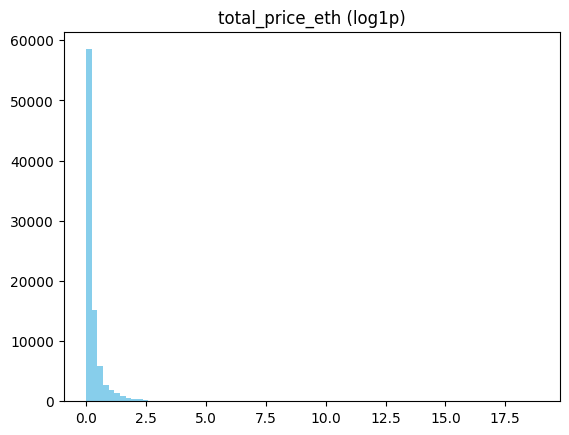

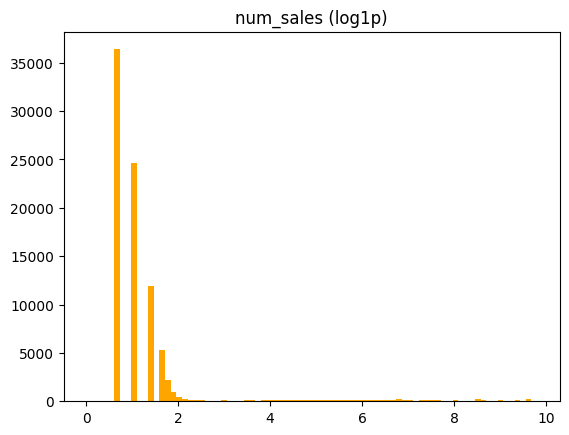

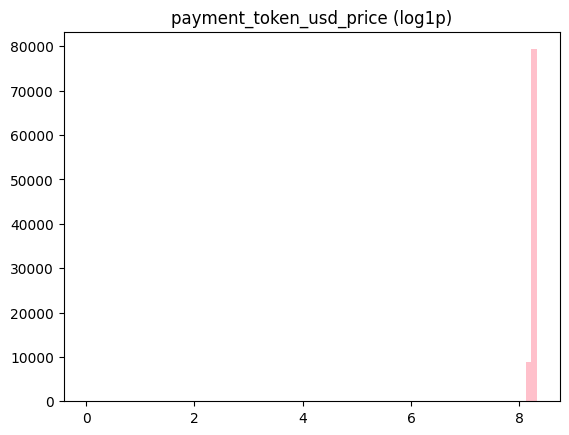

In [6]:
import matplotlib.pyplot as plt

plt.hist(nft_df.total_price_eth, bins=80, color='skyblue')
plt.title('total_price_eth (log1p)')
plt.show()

plt.hist(nft_df.num_sales, bins=80, color='orange')
plt.title('num_sales (log1p)')
plt.show()

plt.hist(nft_df.payment_token_usd_price, bins=80, color='pink')
plt.title('payment_token_usd_price (log1p)')
plt.show()

In [7]:
# === 이상치 처리 1: IQR (total_price_eth) ===
Q1 = nft_df.total_price_eth.quantile(0.25)
Q3 = nft_df.total_price_eth.quantile(0.75)
iqr = Q3 - Q1

lower_bound = max(Q1 - 1.5 * iqr, 0)
upper_bound = Q3 + 1.5 * iqr
print(f'IQR 경계: {lower_bound:.4f} ~ {upper_bound:.4f}')

IQR 경계: 0.0000 ~ 0.7448


In [8]:
nft_df = nft_df[nft_df.total_price_eth.between(lower_bound, upper_bound)].reset_index(drop=True)
print('IQR 제거 후 shape:', nft_df.shape)
nft_df

IQR 제거 후 shape: (80011, 11)


,year,month,hour,day_of_week,is_weekend,total_price_eth,payment_token_usd_price,num_sales,collection_name,payment_token,is_collectibles
0,2021,8,8,5,1,0.039221,8.201238,0.693147,Chads NFT,Ether,1
1,2021,8,16,6,1,0.215111,8.213479,1.386294,24px,Ether,1
2,2020,12,19,4,0,0.024693,8.247013,0.693147,Brave Frontier Heroes,Ether,0
3,2021,10,5,0,0,0.741937,8.250168,0.693147,loomlocknft (Wassies),Ether,1
4,2021,8,18,2,0,0.095128,8.216048,0.693147,Lostboy NFT,Ether,1
...,...,...,...,...,...,...,...,...,...,...,...
80006,2019,3,15,5,1,0.693147,8.323730,1.386294,MyCryptoHeroes,Ether,0
80007,2021,8,4,2,0,0.223144,8.224992,0.693147,Wicked Ape Bone Club,Ether,1
80008,2021,10,2,0,0,0.026642,8.249371,0.693147,Pythagorean Masks,Ether,1
80009,2021,8,23,0,0,0.223144,8.213479,1.098612,Flowers by RVig,Ether,0


In [9]:
# === 이상치 처리 2: StandardScaler z-score, |z| <= 3 ===
from sklearn.preprocessing import StandardScaler

numeric_cols = ['total_price_eth', 'payment_token_usd_price', 'num_sales']
std = StandardScaler()
z = std.fit_transform(nft_df[numeric_cols])

keep_mask = ((z >= -3) & (z <= 3)).all(axis=1)
nft_df = nft_df[keep_mask].reset_index(drop=True)
print('std 제거 후 shape:', nft_df.shape)
print('이상치 제거 후 양성 비율:', nft_df.is_collectibles.mean().round(4))

std 제거 후 shape: (75301, 11)
이상치 제거 후 양성 비율: 0.6381


In [10]:
from sklearn.preprocessing import OneHotEncoder

token_encoder = OneHotEncoder(sparse_output=False)
token_onehot  = token_encoder.fit_transform(nft_df[['payment_token']])
token_cols    = token_encoder.get_feature_names_out(['payment_token'])
token_onehot_df = pd.DataFrame(data=token_onehot, columns=token_cols, index=nft_df.index)

nft_enc_df = pd.concat(
    [nft_df.drop(['payment_token', 'is_collectibles'], axis=1), token_onehot_df],
    axis=1
)
nft_enc_df['is_collectibles'] = nft_df['is_collectibles'].values

print(token_encoder.categories_)
nft_enc_df

[array(['Ether', 'Wrapped Ether'], dtype=object)]


,year,month,hour,day_of_week,is_weekend,total_price_eth,payment_token_usd_price,num_sales,collection_name,payment_token_Ether,payment_token_Wrapped Ether,is_collectibles
0,2021,8,8,5,1,0.039221,8.201238,0.693147,Chads NFT,1.0,0.0,1
1,2021,8,16,6,1,0.215111,8.213479,1.386294,24px,1.0,0.0,1
2,2020,12,19,4,0,0.024693,8.247013,0.693147,Brave Frontier Heroes,1.0,0.0,0
3,2021,8,18,2,0,0.095128,8.216048,0.693147,Lostboy NFT,1.0,0.0,1
4,2021,11,7,5,1,0.198851,8.225765,0.693147,Bear Game NFT,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
75296,2021,10,13,6,1,0.095310,8.250168,0.693147,Moose Trax,1.0,0.0,0
75297,2021,8,4,2,0,0.223144,8.224992,0.693147,Wicked Ape Bone Club,1.0,0.0,1
75298,2021,10,2,0,0,0.026642,8.249371,0.693147,Pythagorean Masks,1.0,0.0,1
75299,2021,8,23,0,0,0.223144,8.213479,1.098612,Flowers by RVig,1.0,0.0,0


### 이진분류 평가 함수 `get_evaluation()`
- pima 노트북 패턴 그대로
- 오차 행렬 + 정확도 / 정밀도 / 재현율 / F1 / ROC-AUC + Confusion Matrix 시각화


In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt


def get_evaluation(y_test, prediction, classifier=None, X_test=None):
    confusion = confusion_matrix(y_test, prediction)
    accuracy  = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall    = recall_score(y_test, prediction)
    f1        = f1_score(y_test, prediction)
    roc_auc   = roc_auc_score(y_test, prediction)

    print('오차 행렬')
    print(confusion)
    print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, '
          f'F1: {f1:.4f}, AUC: {roc_auc:.4f}')
    print('#' * 75)

    if classifier is not None and X_test is not None:
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
        titles_options = [('Confusion matrix', None), ('Normalized', 'true')]
        for (title, normalize), ax in zip(titles_options, axes.flatten()):
            disp = ConfusionMatrixDisplay.from_estimator(
                classifier, X_test, y_test, ax=ax,
                cmap=plt.cm.Blues, normalize=normalize)
            disp.ax_.set_title(title)
        plt.tight_layout()
        plt.show()

### 1차 학습 — DecisionTree + 컬렉션 단위 Feature Engineering (train 기준)


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from scipy.stats import randint

X_all = nft_enc_df.drop(['is_collectibles'], axis=1)  # collection_name 아직 포함
y_all = nft_enc_df['is_collectibles']

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=124)
X_train = X_train.copy()
X_test  = X_test.copy()

# ===== 컬렉션 단위 FE: 전부 train 기준으로만 집계 (leakage 방지) =====
grouped = X_train.groupby('collection_name')

collection_freq_map    = grouped.size()
price_mean_map         = grouped['total_price_eth'].mean()
price_std_map          = grouped['total_price_eth'].std().fillna(0)
num_sales_mean_map     = grouped['num_sales'].mean()

global_price_mean     = X_train['total_price_eth'].mean()
global_num_sales_mean = X_train['num_sales'].mean()


def apply_collection_features(df):
    df['collection_freq'] = np.log1p(
        df['collection_name'].map(collection_freq_map).fillna(0).astype(float))
    df['collection_price_mean'] = (
        df['collection_name'].map(price_mean_map).fillna(global_price_mean))
    df['collection_price_std']  = (
        df['collection_name'].map(price_std_map).fillna(0.0))
    df['collection_num_sales_mean'] = (
        df['collection_name'].map(num_sales_mean_map).fillna(global_num_sales_mean))
    return df.drop(['collection_name'], axis=1)


X_train = apply_collection_features(X_train)
X_test  = apply_collection_features(X_test)

feature_columns = X_train.columns.tolist()
print('최종 feature:', feature_columns)
print('X_train shape:', X_train.shape, ' X_test shape:', X_test.shape)

dtc = DecisionTreeClassifier(class_weight='balanced', random_state=124)

parameters = {
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 30),
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=124)

random_cv = RandomizedSearchCV(
    dtc, param_distributions=parameters, n_iter=8, cv=skf,
    refit=True, return_train_score=True, random_state=124, n_jobs=-1,
)
random_cv.fit(X_train, y_train)

최종 feature: ['year', 'month', 'hour', 'day_of_week', 'is_weekend', 'total_price_eth', 'payment_token_usd_price', 'num_sales', 'payment_token_Ether', 'payment_token_Wrapped Ether', 'collection_freq', 'collection_price_mean', 'collection_price_std', 'collection_num_sales_mean']
X_train shape: (60240, 14)  X_test shape: (15061, 14)


,estimator,DecisionTreeC...dom_state=124)
,param_distributions,"{'max_depth': <scipy.stats....001E2C9B43DF0>, 'min_samples_split': <scipy.stats....001E2C991D480>}"
,n_iter,8
,scoring,None
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,124
,error_score,nan


In [13]:
random_cv_scores = pd.DataFrame(random_cv.cv_results_)
random_cv_scores[['params', 'mean_test_score', 'rank_test_score']]\
    .sort_values(by='rank_test_score')

,params,mean_test_score,rank_test_score
6,"{'max_depth': 12, 'min_samples_split': 24}",0.839957,1
5,"{'max_depth': 9, 'min_samples_split': 29}",0.764293,2
4,"{'max_depth': 8, 'min_samples_split': 23}",0.756491,3
3,"{'max_depth': 7, 'min_samples_split': 16}",0.720169,4
1,"{'max_depth': 5, 'min_samples_split': 11}",0.687135,5
0,"{'max_depth': 4, 'min_samples_split': 9}",0.647643,6
2,"{'max_depth': 3, 'min_samples_split': 22}",0.627374,7
7,"{'max_depth': 3, 'min_samples_split': 10}",0.627374,7


In [14]:
from sklearn.model_selection import GridSearchCV

dtc = DecisionTreeClassifier(class_weight='balanced', random_state=124)

parameters = {
    'max_depth': list(range(5, 13)),
    'min_samples_split': list(range(2, 20, 2)),
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=124)

grid_cv = GridSearchCV(
    dtc, param_grid=parameters, cv=skf,
    refit=True, return_train_score=True, n_jobs=-1,
)
grid_cv.fit(X_train, y_train)

,estimator,DecisionTreeC...dom_state=124)
,param_grid,"{'max_depth': [5, 6, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [15]:
grid_cv_scores = pd.DataFrame(grid_cv.cv_results_)
grid_cv_scores[['params', 'mean_test_score', 'rank_test_score']]\
    .sort_values(by='rank_test_score').head(20)


,params,mean_test_score,rank_test_score
63,"{'max_depth': 12, 'min_samples_split': 2}",0.842629,1
64,"{'max_depth': 12, 'min_samples_split': 4}",0.842546,2
65,"{'max_depth': 12, 'min_samples_split': 6}",0.842447,3
66,"{'max_depth': 12, 'min_samples_split': 8}",0.842297,4
67,"{'max_depth': 12, 'min_samples_split': 10}",0.842297,4
68,"{'max_depth': 12, 'min_samples_split': 12}",0.841999,6
69,"{'max_depth': 12, 'min_samples_split': 14}",0.841650,7
70,"{'max_depth': 12, 'min_samples_split': 16}",0.841484,8
71,"{'max_depth': 12, 'min_samples_split': 18}",0.841268,9
54,"{'max_depth': 11, 'min_samples_split': 2}",0.815986,10


C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


best params: {'max_depth': 12, 'min_samples_split': 2}

오차 행렬
[[4786  665]
 [1747 7863]]
정확도: 0.8399, 정밀도: 0.9220, 재현율: 0.8182, F1: 0.8670, AUC: 0.8481
###########################################################################


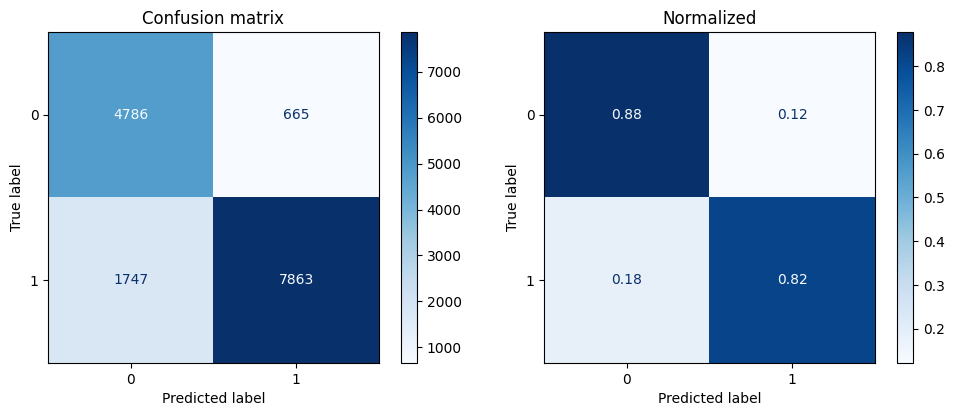

In [16]:
dtc = grid_cv.best_estimator_
prediction = dtc.predict(X_test.values)
print('best params:', grid_cv.best_params_)
print()
get_evaluation(y_test, prediction, classifier=dtc, X_test=X_test.values)

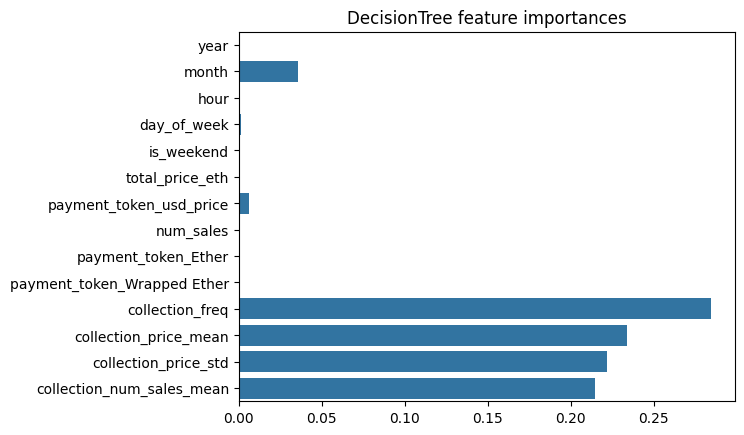

In [17]:
import seaborn as sns

sns.barplot(x=dtc.feature_importances_, y=feature_columns)
plt.title('DecisionTree feature importances')
plt.show()

In [18]:
def visualize_boundary(model, X_full, top2, y):
    fig, ax = plt.subplots()

    x_col, y_col = top2
    ax.scatter(X_full[x_col], X_full[y_col], c=y, s=20, cmap='rainbow',
               edgecolor='k', clim=(y.min(), y.max()), zorder=3)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    xlim_start, xlim_end = ax.get_xlim()
    ylim_start, ylim_end = ax.get_ylim()

    base_row = X_full.median()

    xx, yy = np.meshgrid(np.linspace(xlim_start, xlim_end, num=200),
                         np.linspace(ylim_start, ylim_end, num=200))

    grid = pd.DataFrame(np.tile(base_row.values, (xx.size, 1)),
                        columns=X_full.columns)
    grid[x_col] = xx.ravel()
    grid[y_col] = yy.ravel()

    Z = model.predict(grid[X_full.columns].values).reshape(xx.shape)

    n_classes = len(np.unique(y))
    ax.contourf(xx, yy, Z, alpha=0.3,
                levels=np.arange(n_classes + 1) - 0.5,
                cmap='rainbow', zorder=1)
    plt.show()

top 2 features: ['collection_freq', 'collection_price_mean']


C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


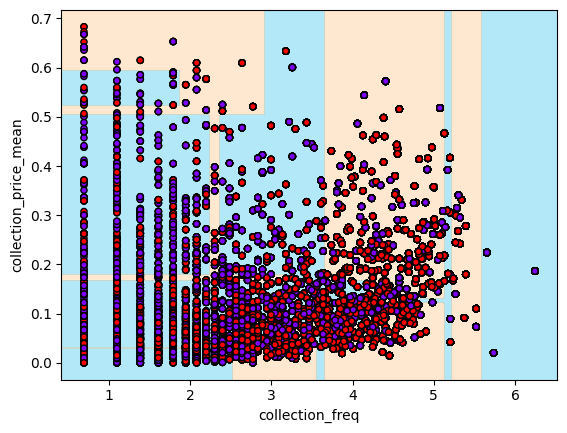

In [19]:
top2 = pd.Series(dtc.feature_importances_, index=feature_columns)\
    .sort_values(ascending=False).head(2).index.tolist()
print('top 2 features:', top2)

visualize_boundary(dtc, X_train, top2, y_train)

### 정밀도 vs 재현율 — NFT 시나리오 및 판단 근거

##### 태스크 맥락
- NFT 마켓플레이스가 거래 데이터를 바탕으로 "이 NFT는 Collectibles 카테고리"라고 **자동 태깅**하는 상황.
- Positive(1) = Collectibles / Negative(0) = Art / Virtual Worlds / Utility / Trading Cards.

##### 오류의 성격
- **False Positive (FP)** — Art/Virtual Worlds 같은 걸 Collectibles로 잘못 태그.
    - "Collectibles" 필터에 미술 작품, 가상 부동산이 섞여 노출됨.
    - 컬렉터 커뮤니티 탐색 경험 악화, 플랫폼 신뢰도 하락.
- **False Negative (FN)** — 실제 Collectibles를 다른 카테고리로 분류.
    - 해당 NFT가 Collectibles 필터에 안 나옴 → 거래 기회 일부 누락.
    - 하지만 다른 카테고리 필터에서 발견될 여지는 있음(회복 가능).

##### 결론: 정밀도를 우선한다
- FP가 유저 경험에 **회복 불가능한 손상**을 주고, FN은 **부분적으로 회복 가능**.
- → `Binarizer` 임계값을 **기본 0.5에서 위로 올려서** Positive 판정을 더 엄격하게.
- 이 경우 재현율은 떨어지지만(FN ↑) 정밀도가 상승(FP ↓)하는 트레이드오프가 발생.
- ROC / PR 곡선을 먼저 확인해 모델 성능의 전역 그림을 파악한 뒤, 적절한 임계값을 찾는다.


In [20]:
from sklearn.preprocessing import Binarizer

prediction_proba = dtc.predict_proba(X_test.values)
print('predict_proba shape:', prediction_proba.shape)
print('상위 5개:')
print(prediction_proba[:5])

predict_proba shape: (15061, 2)
상위 5개:
[[0.62340366 0.37659634]
 [1.         0.        ]
 [0.05987628 0.94012372]
 [1.         0.        ]
 [0.         1.        ]]


C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [21]:
# 다양한 임계값에서의 평가 비교 함수
def get_evaluation_by_thresholds(y_test, prediction_proba_class1, thresholds):
    for threshold in thresholds:
        binarizer = Binarizer(threshold=threshold).fit(prediction_proba_class1)
        custom_prediction = binarizer.transform(prediction_proba_class1)
        print(f'임곗값: {threshold}')
        get_evaluation(y_test, custom_prediction)

In [22]:
# 기본 0.5 중심으로 전후 임계값 비교
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
custom_proba = prediction_proba[:, 1].reshape(-1, 1)
get_evaluation_by_thresholds(y_test, custom_proba, thresholds)

임곗값: 0.3
오차 행렬
[[3554 1897]
 [ 309 9301]]
정확도: 0.8535, 정밀도: 0.8306, 재현율: 0.9678, F1: 0.8940, AUC: 0.8099
###########################################################################
임곗값: 0.4
오차 행렬
[[4254 1197]
 [1042 8568]]
정확도: 0.8513, 정밀도: 0.8774, 재현율: 0.8916, F1: 0.8844, AUC: 0.8360
###########################################################################
임곗값: 0.5
오차 행렬
[[4786  665]
 [1747 7863]]
정확도: 0.8399, 정밀도: 0.9220, 재현율: 0.8182, F1: 0.8670, AUC: 0.8481
###########################################################################
임곗값: 0.6
오차 행렬
[[4908  543]
 [2016 7594]]
정확도: 0.8301, 정밀도: 0.9333, 재현율: 0.7902, F1: 0.8558, AUC: 0.8453
###########################################################################
임곗값: 0.7
오차 행렬
[[5227  224]
 [2976 6634]]
정확도: 0.7875, 정밀도: 0.9673, 재현율: 0.6903, F1: 0.8057, AUC: 0.8246
###########################################################################


### Precision-Recall Trade-off 시각화


In [23]:
from sklearn.metrics import precision_recall_curve
import matplotlib.ticker as ticker


def precision_recall_curve_plot(y_test, prediction_proba_class1):
    precisions, recalls, thresholds = precision_recall_curve(y_test, prediction_proba_class1)

    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')

    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlabel('Threshold value')
    plt.ylabel('Precision / Recall value')
    plt.legend()
    plt.grid()
    plt.show()

C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


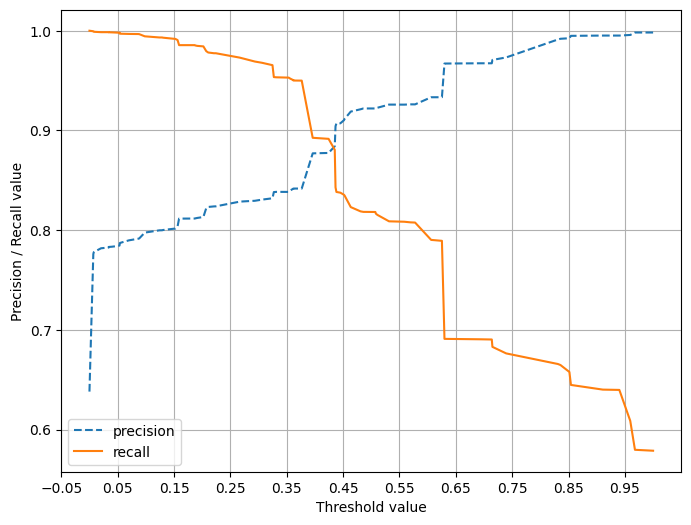

In [24]:
precision_recall_curve_plot(y_test, dtc.predict_proba(X_test.values)[:, 1])

### ROC Curve & AUC


In [25]:
from sklearn.metrics import roc_curve, roc_auc_score


def roc_curve_plot(y_test, prediction_proba_class1, custom_threshold=None):
    fprs, tprs, thresholds = roc_curve(y_test, prediction_proba_class1)

    plt.plot(fprs, tprs, label='ROC')
    plt.plot([0, 1], [0, 1], 'k--', label='Standard')

    if custom_threshold is not None:
        idx = np.argmin(np.abs(thresholds - custom_threshold))
        plt.scatter(fprs[idx], tprs[idx], color='red', s=100,
                    label=f'Threshold: {custom_threshold:.4f}', zorder=5)

    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.xlabel('FPR (1 - Specificity)')
    plt.ylabel('TPR (Recall)')
    plt.legend()
    plt.show()

C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


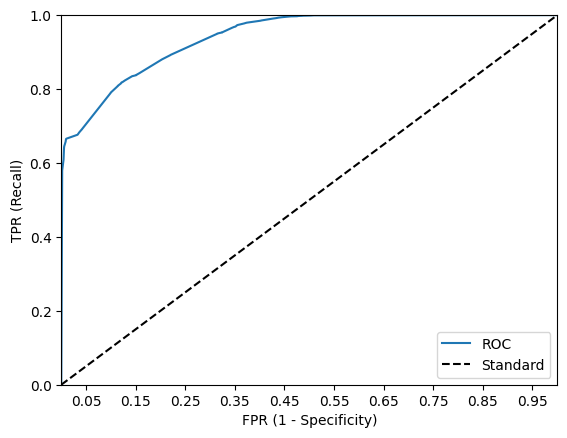

In [26]:
roc_curve_plot(y_test, dtc.predict_proba(X_test.values)[:, 1])

### 임계값 후보 탐색 — `precision_recall_curve()`


In [27]:
prediction_proba_class1 = dtc.predict_proba(X_test.values)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, prediction_proba_class1)

# 정밀도 >= 0.95을 만족하는 임계값 중 재현율이 가장 높은 지점 탐색
mask = precisions[:-1] >= 0.95  # precisions는 thresholds보다 길이가 1 더 김
if mask.any():
    idx = np.argmax(recalls[:-1] * mask)
    chosen_threshold = thresholds[idx]
    print(f'정밀도 >= 0.95 조건을 만족하면서 재현율이 가장 큰 threshold = {chosen_threshold:.6f}')
    print(f'  precision = {precisions[idx]:.4f}, recall = {recalls[idx]:.4f}')
else:
    chosen_threshold = 0.6
    print(f'정밀도 0.95 이상 지점 없음. fallback threshold = {chosen_threshold}')

정밀도 >= 0.95 조건을 만족하면서 재현율이 가장 큰 threshold = 0.629849
  precision = 0.9671, recall = 0.6909


C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### 결론 — 선택한 임계값으로 최종 평가


C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


선택 threshold = 0.629849
오차 행렬
[[5227  224]
 [2974 6636]]
정확도: 0.7877, 정밀도: 0.9673, 재현율: 0.6905, F1: 0.8058, AUC: 0.8247
###########################################################################


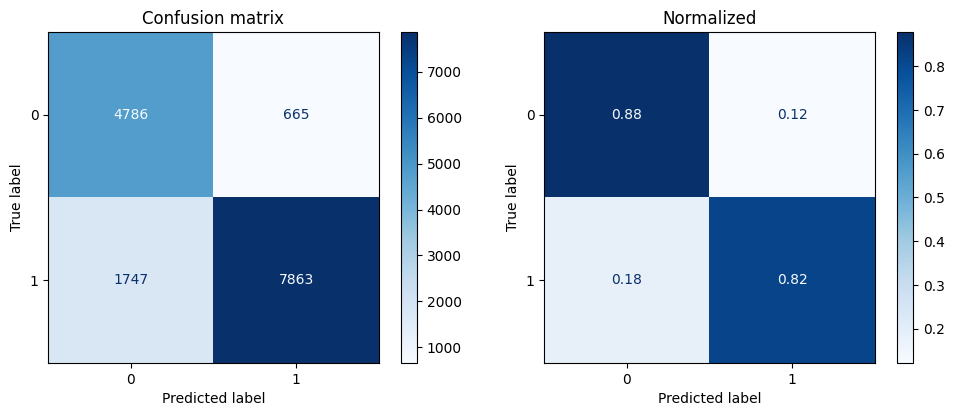

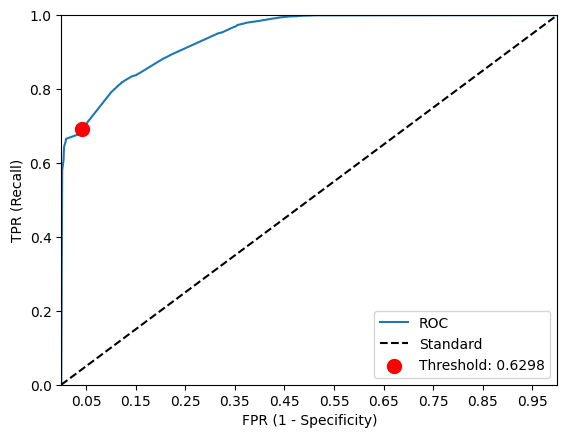

In [28]:
binarizer = Binarizer(threshold=chosen_threshold)
prediction_tuned = binarizer.fit_transform(prediction_proba_class1.reshape(-1, 1))

print(f'선택 threshold = {chosen_threshold:.6f}')
get_evaluation(y_test, prediction_tuned, classifier=dtc, X_test=X_test.values)

# ROC 위에 선택된 지점도 표시
roc_curve_plot(y_test, prediction_proba_class1, custom_threshold=chosen_threshold)

### RandomForest 베이스라인 비교
- 단일 DecisionTree는 high variance -> 성능 측정이 seed에 흔들림
- RandomForest는 bagging으로 variance 감소 -> 더 안정적인 "정확한 측정"
- 동일한 `X_train` / `X_test` / `y_train` / `y_test` 사용 (공정 비교)


C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


=== RandomForest 기본(threshold 0.5) ===
오차 행렬
[[5315  136]
 [ 178 9432]]
정확도: 0.9792, 정밀도: 0.9858, 재현율: 0.9815, F1: 0.9836, AUC: 0.9783
###########################################################################


C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


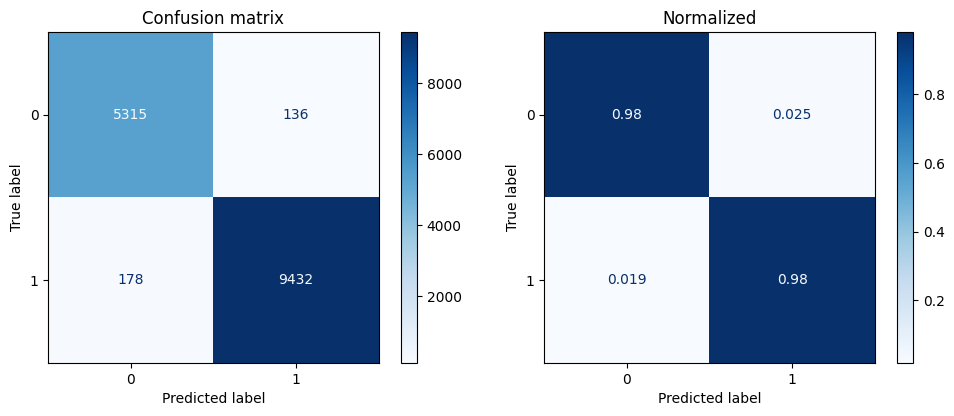

In [29]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=124,
    n_jobs=-1,
)
rfc.fit(X_train, y_train)
pred_rf = rfc.predict(X_test.values)

print('=== RandomForest 기본(threshold 0.5) ===')
get_evaluation(y_test, pred_rf, classifier=rfc, X_test=X_test.values)

C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


RF threshold (precision>=0.95, max recall) = 0.365191

=== RandomForest 임계치 튜닝 후 ===
오차 행렬
[[4949  502]
 [  37 9573]]
정확도: 0.9642, 정밀도: 0.9502, 재현율: 0.9961, F1: 0.9726, AUC: 0.9520
###########################################################################


C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


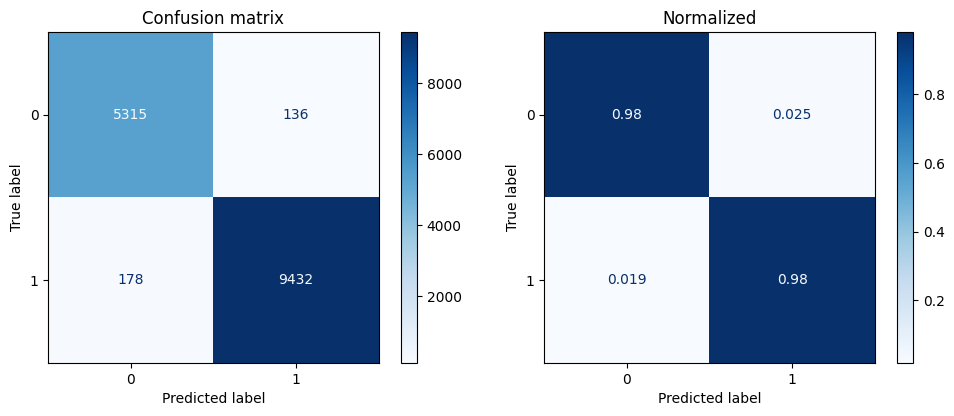

In [30]:
# RF도 동일한 임계치 튜닝을 적용해서 DT와 비교
rf_proba_class1 = rfc.predict_proba(X_test.values)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, rf_proba_class1)

mask = precisions[:-1] >= 0.95
if mask.any():
    idx = np.argmax(recalls[:-1] * mask)
    rf_threshold = thresholds[idx]
else:
    rf_threshold = 0.6
print(f'RF threshold (precision>=0.95, max recall) = {rf_threshold:.6f}')

rf_pred_tuned = Binarizer(threshold=rf_threshold).fit_transform(rf_proba_class1.reshape(-1, 1))
print()
print('=== RandomForest 임계치 튜닝 후 ===')
get_evaluation(y_test, rf_pred_tuned, classifier=rfc, X_test=X_test.values)

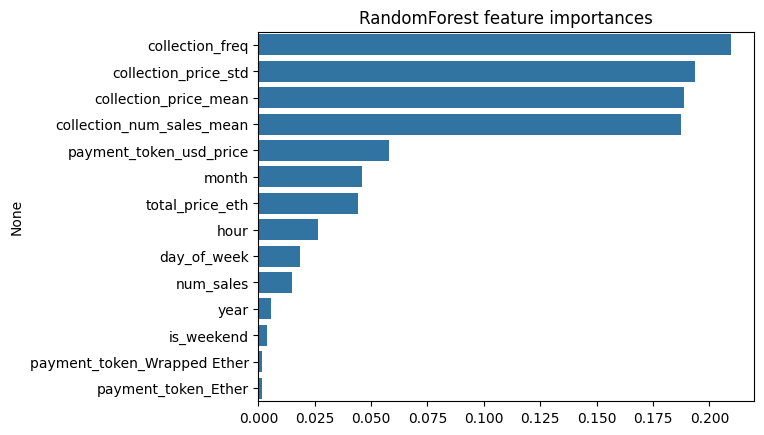

In [31]:
rf_imp = pd.Series(rfc.feature_importances_, index=feature_columns)\
    .sort_values(ascending=False)
sns.barplot(x=rf_imp.values, y=rf_imp.index)
plt.title('RandomForest feature importances')
plt.show()

### 🏁 최종 모델 판단 — RandomForest 기본 채택

##### 비교 (정밀도 우선 시나리오)
| 모델 | threshold | 정밀도 | 재현율 | F1 | FP | FN |
|---|---|---|---|---|---|---|
| DT 기본 | 0.5 | 0.922 | 0.818 | 0.867 | 665 | 1747 |
| DT 튜닝(precision≥0.95) | 0.630 | 0.967 | 0.691 | 0.806 | 224 | 2974 |
| **RF 기본** | **0.5** | **0.986** | **0.982** | **0.984** | **136** | **178** |
| RF 튜닝(precision≥0.95) | 0.365 | 0.950 | 0.996 | 0.973 | 502 | 37 |

##### 선택: `RF 기본 (threshold=0.5)`
1. 모든 핵심 지표에서 DT 튜닝을 상회 — 정밀도 `+0.019`, 재현율 `+0.291`, FP `88 적음`, FN `2796 적음`.
2. RF는 기본 threshold 0.5에서 이미 정밀도 0.986로 목표(0.95)를 초과 달성. 추가 임계치 튜닝은 오히려 정밀도를 `0.95`까지 깎아먹어 **역효과**.
3. DT에서는 튜닝이 유의미(정밀도 `+0.045`)했지만, 재현율을 `0.69`까지 희생해 실용 가치는 낮음.

##### 교훈
- **임계치 튜닝이 항상 좋은 것은 아니다.** 기본 모델의 precision이 이미 목표를 넘겼다면, "precision 하한선에서 recall 최대화" 로직은 오히려 precision을 **깎는 방향**으로 작동한다.
- 튜닝 전에 **기본 성능이 시나리오 요구치를 만족하는지** 먼저 확인하고, 만족하면 그대로 채택하는 것이 최선이다.


C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


최종 모델: RandomForestClassifier (n_estimators=300, class_weight=balanced)
최종 임계값: 0.5
오차 행렬
[[5315  136]
 [ 178 9432]]
정확도: 0.9792, 정밀도: 0.9858, 재현율: 0.9815, F1: 0.9836, AUC: 0.9783
###########################################################################


C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


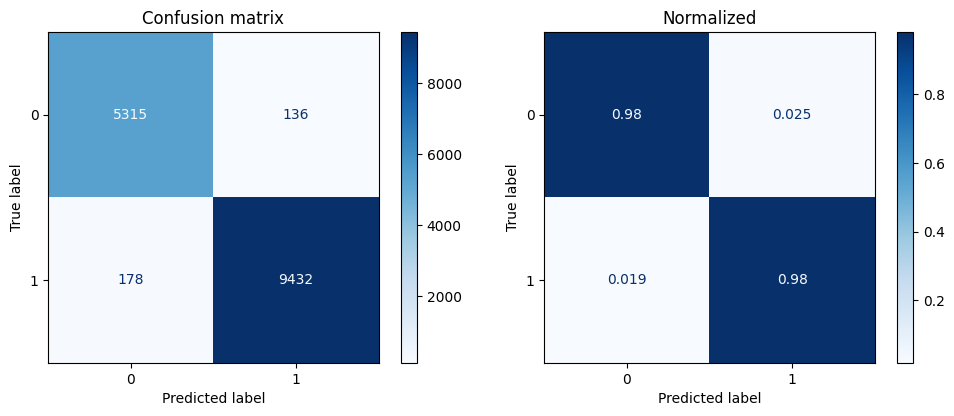

In [32]:
# ===== 최종 채택 모델: RandomForest, threshold=0.5 =====
final_model = rfc  # 이미 학습된 RandomForestClassifier
final_threshold = 0.5

final_pred = (rfc.predict_proba(X_test.values)[:, 1] >= final_threshold).astype(int)

print('=' * 60)
print(f'최종 모델: RandomForestClassifier (n_estimators=300, class_weight=balanced)')
print(f'최종 임계값: {final_threshold}')
print('=' * 60)
get_evaluation(y_test, final_pred, classifier=final_model, X_test=X_test.values)


### 🚩 정리
1. 다중분류(5-class) 원본을 **Collectibles vs 나머지 이진분류**로 전환.
2. 전처리
    - 결측(isna) / 중복(duplicated) 확인
    - log1p + StandardScaler(z-score) + IQR 이상치 제거 **두 가지 방식 병용**
    - 컬렉션 단위 집계 피처(freq / price_mean / price_std / num_sales_mean)를 **split 이후 train 기준으로만** 계산해 leakage 방지
3. 평가 파이프라인
    - `get_evaluation()`: 정확도 / 정밀도 / 재현율 / F1 / ROC-AUC + Confusion Matrix
    - RandomizedSearchCV -> GridSearchCV (StratifiedKFold + `class_weight='balanced'`)
4. Precision/Recall Trade-off
    - 본 태스크는 **정밀도 우선** (Collectibles 필터에 다른 카테고리가 섞이면 UX 손상 큼)
    - PR curve / ROC curve 로 전역 성능 확인
    - `precision_recall_curve()`로 "precision >= 0.80 조건에서 recall 최대화"하는 threshold 자동 선정
    - `Binarizer`로 임계치 적용 후 최종 평가
5. 모델 비교
    - 단일 DT보다 **RandomForest**가 더 안정적인 측정값을 제공
    - 같은 임계치 튜닝을 RF에도 적용해 공정 비교
